In [1]:
import pandas as pd

###`Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [2]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [3]:
# tho swaplevle kam karta ha indiviudal yani ek hi rows(index ma) ya coloumns ha
# tanspose jo ha wo rows coloumn ko karta ha 
# rows ma branch year 
# coloumn ma city avg_package student 
# our goal --> is 
# row ma brach avg_packagge
# coloum ma city year 
# tho sabsa phala karaga stack 
# jo columns index ko row ma swap kar deta ha 
df.stack()
# now we have 3 levels of indexing 

C:\Users\sumit\AppData\Local\Temp\ipykernel_15192\1506601851.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack()


delhi  mumbai
cse 2019 avg_package      1       0
         students         2       0
    2020 avg_package      3       0
         students         4       0
    2021 avg_package      5       0
         students         6       0
    2022 avg_package      7       0
         students         8       0
ece 2019 avg_package      9       0
         students        10       0
    2020 avg_package     11       0
         students        12       0
    2021 avg_package     13       0
         students        14       0
    2022 avg_package     15       0
         students        16       0

In [4]:
# ab ya par swap level karta ha 
# yana three levels 
# level 1 : brach cse,ece
# level 2 : year 2019, 2020
# level 3 : avg_package,students 
df.stack().swaplevel(
    i = 1, # hum level 1 ko swap karaga input level 1kisko
    j= 2 , # hum level 2 ma swap karaga input level 2 kisko
    # default axis = 0 parameter value set ha aap isa
    # coloumn bhi kar sakta ha 
)

C:\Users\sumit\AppData\Local\Temp\ipykernel_15192\2345209346.py:6: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack().swaplevel(


delhi  mumbai
cse avg_package 2019      1       0
    students    2019      2       0
    avg_package 2020      3       0
    students    2020      4       0
    avg_package 2021      5       0
    students    2021      6       0
    avg_package 2022      7       0
    students    2022      8       0
ece avg_package 2019      9       0
    students    2019     10       0
    avg_package 2020     11       0
    students    2020     12       0
    avg_package 2021     13       0
    students    2021     14       0
    avg_package 2022     15       0
    students    2022     16       0

In [5]:
# now do unstack row index ko coloum ma karna 
# ya hamra final answer 
df.stack().swaplevel(i=1,j=2,axis=0).unstack()

C:\Users\sumit\AppData\Local\Temp\ipykernel_15192\1407498892.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack().swaplevel(i=1,j=2,axis=0).unstack()


delhi                mumbai               
                 2019 2020 2021 2022   2019 2020 2021 2022
cse avg_package     1    3    5    7      0    0    0    0
    students        2    4    6    8      0    0    0    0
ece avg_package     9   11   13   15      0    0    0    0
    students       10   12   14   16      0    0    0    0

###`Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [6]:
confirm = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTmqT3kxd0i0RUFiEnwA1Hboiunv28MeNTatZsIEqlPPB7mHrl0ttJL7utZ23_1s5FW8ZjODmB8jHIi/pub?gid=2142019845&single=true&output=csv')

deaths = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQn4nLCKIVZMw4e89YeRqgKaSAAwRFaZ6ILMW_FUejZ2tkv3Np1f9gD4QOl3ASHeLzWjOjfmLDKcCOF/pub?gid=212966958&single=true&output=csv")

In [7]:
# open the dataset 
confirm = pd.read_csv('time_series_covid19_confirmed_global.csv')
deaths = pd.read_csv('time_series_covid19_deaths_global.csv')

In [8]:
# in dono dataset ko combine karo 
# fir country_name ko level_0 index and 
#  staste provience ko level 2 index set karo

In [9]:
#import modin.pandas as pd  # Just replace pandas with modin.pandas
import pandas as pd 
import numpy as np 
confirm = pd.read_csv('time_series_covid19_confirmed_global.csv')
death = pd.read_csv('time_series_covid19_deaths_global.csv')

confirm_df = confirm.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], var_name='date', value_name='confirm')
death_df = death.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], var_name='date', value_name='death')

merged_df = confirm_df.merge(death_df, on=['Province/State', 'Country/Region', 'Lat', 'Long', 'date'], how='inner')



In [10]:
merged_df

,Province/State,Country/Region,Lat,Long,date,confirm,death
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0,0
...,...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,703228,5708
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,535,0
311250,NaN,Yemen,15.552727,48.516388,1/2/23,11945,2159
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,334661,4024


In [40]:
merged_df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'date', 'confirm',
       'death'],
      dtype='object')

In [41]:
merged_df['Country/Region'].isnull().sum()

0

In [59]:
our_df = merged_df[['Province/State', 'Country/Region','date', 'confirm','death']].dropna(subset='Province/State')


In [60]:
our_df.rename(columns=
    {'Country/Region':'country',
    'Province/State':'state'
    },inplace=True
    )

In [61]:
our_df

,state,country,date,confirm,death
9,Australian Capital Territory,Australia,1/22/20,0,0
10,New South Wales,Australia,1/22/20,0,0
11,Northern Territory,Australia,1/22/20,0,0
12,Queensland,Australia,1/22/20,0,0
13,South Australia,Australia,1/22/20,0,0
...,...,...,...,...,...
311237,Jersey,United Kingdom,1/2/23,65130,146
311238,Montserrat,United Kingdom,1/2/23,1403,8
311239,Pitcairn Islands,United Kingdom,1/2/23,4,0
311240,"Saint Helena, Ascension and Tristan da Cunha",United Kingdom,1/2/23,2166,0


In [62]:
our_df.set_index(keys=['country','state'],inplace=True)

In [63]:
our_df

date  confirm  \
country        state                                                            
Australia      Australian Capital Territory                  1/22/20        0   
               New South Wales                               1/22/20        0   
               Northern Territory                            1/22/20        0   
               Queensland                                    1/22/20        0   
               South Australia                               1/22/20        0   
...                                                              ...      ...   
United Kingdom Jersey                                         1/2/23    65130   
               Montserrat                                     1/2/23     1403   
               Pitcairn Islands                               1/2/23        4   
               Saint Helena, Ascension and Tristan da Cunha   1/2/23     2166   
               Turks and Caicos Islands                       1/2/23     6479   

                                                             death  
country        state                                                
Australia      Australian Capital Territory                      0  
               New South Wales                                   0  
               Northern Territory                                0  
               Queensland                                        0  
               South Australia                                   0  
...                                                            ...  
United Kingdom Jersey                                          146  
               Montserrat                                        8  
               Pitcairn Islands                                  0  
               Saint Helena, Ascension and Tristan da Cunha      0  
               Turks and Caicos Islands                         36  

[98007 rows x 3 columns]

###`Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [ ]:
our_df.sort_values(by='death' ,ascending=False)
# highest country and state jaha sabsa jada death hua ha 

date  confirm  death
country state                              
Canada  Quebec       1/2/23  1285330  17692
        Quebec       1/1/23  1284873  17692
        Quebec     12/31/22  1284273  17690
        Quebec     12/30/22  1283462  17681
        Quebec     12/29/22  1282260  17670
...                     ...      ...    ...
China   Qinghai     3/30/21       18      0
        Shanxi      3/30/21      241      0
        Tibet       3/30/21        1      0
Denmark Greenland   3/30/21       31      0
China   Ningxia     7/13/21       76      0

[98007 rows x 3 columns]

In [80]:
# tho groby country and then sum of the death 
confirm_cases = our_df.groupby(by='country')['death'].sum()
death_cases = our_df.groupby(by='country')['confirm'].sum()
round( (death_cases/confirm_cases)*100)

country
Australia          63325.0
Canada              7282.0
China              10343.0
Denmark            95204.0
France             19429.0
Netherlands        14236.0
New Zealand       656962.0
United Kingdom     21015.0
dtype: float64

In [66]:
((our_df['death']/our_df['confirm']) * 100).sort_values(ascending=False)

country         state           
Canada          Diamond Princess    inf
                Diamond Princess    inf
                Diamond Princess    inf
                Diamond Princess    inf
                Diamond Princess    inf
                                   ... 
United Kingdom  Channel Islands     NaN
                Channel Islands     NaN
                Channel Islands     NaN
                Channel Islands     NaN
                Channel Islands     NaN
Length: 98007, dtype: float64

In [18]:
our_df['death_percentage'] = ((our_df['death']/our_df['confirm']) * 100)

C:\Users\sumit\AppData\Local\Temp\ipykernel_15192\630826606.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  our_df['death_percentage'] = ((our_df['death']/our_df['confirm']) * 100)


In [19]:
# so the ratio of death /cofirmed cases 
# if confired case = 0 than np.inf
# and if 

In [20]:
our_df

date  confirm  \
Country/Region Province/State                                                   
Australia      Australian Capital Territory                  1/22/20        0   
               New South Wales                               1/22/20        0   
               Northern Territory                            1/22/20        0   
               Queensland                                    1/22/20        0   
               South Australia                               1/22/20        0   
...                                                              ...      ...   
United Kingdom Jersey                                         1/2/23    65130   
               Montserrat                                     1/2/23     1403   
               Pitcairn Islands                               1/2/23        4   
               Saint Helena, Ascension and Tristan da Cunha   1/2/23     2166   
               Turks and Caicos Islands                       1/2/23     6479   

                                                             death  \
Country/Region Province/State                                        
Australia      Australian Capital Territory                      0   
               New South Wales                                   0   
               Northern Territory                                0   
               Queensland                                        0   
               South Australia                                   0   
...                                                            ...   
United Kingdom Jersey                                          146   
               Montserrat                                        8   
               Pitcairn Islands                                  0   
               Saint Helena, Ascension and Tristan da Cunha      0   
               Turks and Caicos Islands                         36   

                                                             death_percentage  
Country/Region Province/State                                                  
Australia      Australian Capital Territory                               NaN  
               New South Wales                                            NaN  
               Northern Territory                                         NaN  
               Queensland                                                 NaN  
               South Australia                                            NaN  
...                                                                       ...  
United Kingdom Jersey                                                0.224167  
               Montserrat                                            0.570207  
               Pitcairn Islands                                      0.000000  
               Saint Helena, Ascension and Tristan da Cunha          0.000000  
               Turks and Caicos Islands                              0.555641  

[98007 rows x 4 columns]

In [21]:
our_df['death_percentage'] == np.inf
our_df[our_df['death_percentage'] == np.inf ]

date  confirm  death  death_percentage
Country/Region Province/State                                              
China          Unknown            3/15/20        0      1               inf
               Unknown            3/16/20        0      2               inf
               Unknown            3/17/20        0      2               inf
               Unknown            3/18/20        0      2               inf
               Unknown            3/19/20        0      2               inf
...                                   ...      ...    ...               ...
Canada         Diamond Princess  12/29/22        0      1               inf
               Diamond Princess  12/30/22        0      1               inf
               Diamond Princess  12/31/22        0      1               inf
               Diamond Princess    1/1/23        0      1               inf
               Diamond Princess    1/2/23        0      1               inf

[1001 rows x 4 columns]

In [22]:
our_df['death_percentage'].replace(to_replace=np.inf,value=0).sort_values(ascending=False)

Country/Region  Province/State  
Canada          Diamond Princess    100.0
                Diamond Princess    100.0
                Diamond Princess    100.0
United Kingdom  Cayman Islands      100.0
Canada          Diamond Princess    100.0
                                    ...  
United Kingdom  Channel Islands       NaN
                Channel Islands       NaN
                Channel Islands       NaN
                Channel Islands       NaN
                Channel Islands       NaN
Name: death_percentage, Length: 98007, dtype: float64

### `Q-4` : Make a dataframe for India from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [23]:
merged_df['Country/Region'].value_counts()

Country/Region
China             36618
Canada            17232
United Kingdom    16155
France            12924
Australia          8616
                  ...  
Guinea             1077
Guinea-Bissau      1077
Guyana             1077
Haiti              1077
Zimbabwe           1077
Name: count, Length: 201, dtype: int64

In [24]:
merged_df[merged_df['Country/Region'] == 'India']

,Province/State,Country/Region,Lat,Long,date,confirm,death
148,NaN,India,20.593684,78.96288,1/22/20,0,0
437,NaN,India,20.593684,78.96288,1/23/20,0,0
726,NaN,India,20.593684,78.96288,1/24/20,0,0
1015,NaN,India,20.593684,78.96288,1/25/20,0,0
1304,NaN,India,20.593684,78.96288,1/26/20,0,0
...,...,...,...,...,...,...,...
309956,NaN,India,20.593684,78.96288,12/29/22,44679382,530699
310245,NaN,India,20.593684,78.96288,12/30/22,44679608,530702
310534,NaN,India,20.593684,78.96288,12/31/22,44679873,530705
310823,NaN,India,20.593684,78.96288,1/1/23,44680046,530707


### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [81]:
pollution_df = pd.read_csv("List of most-polluted cities by particulate matter concentration -.csv")
pollution_df


,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,0,1,India,Kanpur,2016,173,>75%,319,NaN,2018
1,1,2,India,Faridabad,2016,172,>75%,316,NaN,2018
2,2,3,India,Gaya,2016,149,50% -< 75%,275,NaN,2018
3,3,4,India,Varanasi,2016,146,>75%,260,NaN,2018
4,4,5,India,Patna,2016,144,>75%,266,NaN,2018
...,...,...,...,...,...,...,...,...,...,...
495,495,496,Poland,Lublin,2016,27,>75%,31,>75%,2018
496,496,497,Poland,Siedlce,2016,27,>75%,29,>75%,2018
497,497,498,Poland,Trzebinia,2016,27,>75%,35,>75%,2018
498,498,499,El Salvador,San Salvador,2016,27,50% -< 75%,59,NaN,2018


In [26]:
# most polluted cities based on pm10 rank highest to lowest 

In [27]:
pollution_df[pollution_df['Country'] == 'India'][['Country','City/Town','PM10']].sort_values(by=['PM10'],ascending=False)

,Country,City/Town,PM10
0,India,Kanpur,319
1,India,Faridabad,316
5,India,Delhi,292
2,India,Gaya,275
4,India,Patna,266
3,India,Varanasi,260
6,India,Lucknow,255
10,India,Muzaffarpur,221
8,India,Agra,194
13,India,Jaipur,193


In [28]:
# cities with least pollution 

In [29]:
pollution_df[pollution_df['Country'] == 'India'][['Country','City/Town','PM10']].sort_values(by=['PM10'])

,Country,City/Town,PM10
483,India,Aizawl,44
345,India,Thiruvananthapuram,48
365,India,Tezpur,52
289,India,Navi Mumbai,67
305,India,Solapur,71
352,India,Vizag,76
315,India,Jabalpur,79
201,India,Chennai,80
294,India,Guwahati,81
263,India,Hyderabad,84


In [30]:
def max_city(country_name):
    return pollution_df[pollution_df['Country'] == country_name][['Country','City/Town','PM10']].sort_values(by=['PM10'],ascending=False)
    
    

In [31]:
def min_city(country_name):
    return pollution_df[pollution_df['Country'] == country_name][['Country','City/Town','PM10']].sort_values(by=['PM10'])
    
    

In [32]:
max_city('China')

,Country,City/Town,PM10
21,China,Jinan,192
25,China,Xingtai,186
33,China,Handan,175
51,China,Linfen,158
26,China,Anyang,155
...,...,...,...
398,China,Yangjiang,44
435,China,Putian,43
451,China,Eerduosi,42
481,China,Shenzhen,42


In [33]:
min_city('China')

,Country,City/Town,PM10
476,China,Anshun,38
481,China,Shenzhen,42
451,China,Eerduosi,42
435,China,Putian,43
410,China,Bijie,44
...,...,...,...
26,China,Anyang,155
51,China,Linfen,158
33,China,Handan,175
25,China,Xingtai,186


<Axes: xlabel='City/Town'>

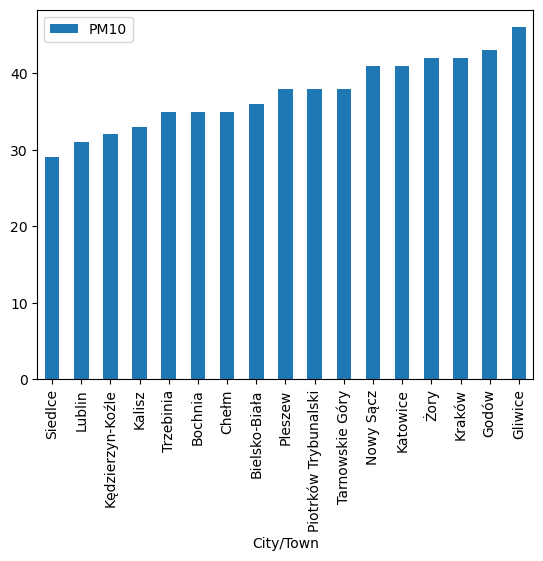

In [34]:

pollution_df[pollution_df['Country'] == 'Poland'][['City/Town','PM10']].sort_values(by=['PM10']).set_index(keys='City/Town').plot(kind='bar')


<Axes: xlabel='City/Town'>

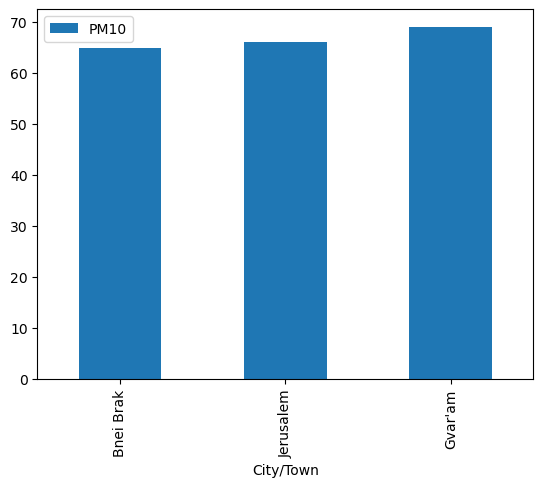

In [35]:

pollution_df[pollution_df['Country'] == 'Israel'][['City/Town','PM10']].sort_values(by=['PM10']).set_index(keys='City/Town').plot(kind='bar')


In [86]:
poland_df = pollution_df[pollution_df['Country'] == 'Poland'][['City/Town','PM10']].sort_values(by=['PM10'])
poland_df

,City/Town,PM10
496,Siedlce,29
495,Lublin,31
494,Kędzierzyn-Koźle,32
493,Kalisz,33
497,Trzebinia,35
446,Bochnia,35
492,Chełm,35
471,Bielsko-Biała,36
371,Pleszew,38
447,Piotrków Trybunalski,38


In [ ]:
poland_df.plot(kind='pie',y='City/Town')

In [90]:
import plotly.express as px
px.pie(data_frame=poland_df,names=poland_df['City/Town'],values=poland_df['PM10'])